In [4]:


import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor

import tensorflow as tf
from keras.layers import (
    Dense,
    Input,
    Embedding,
    Flatten,
    Concatenate,
    Dropout,
    LayerNormalization,
    Add,
    Activation,
)
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from keras.regularizers import l2

_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.isdir(os.path.join(_ROOT, "archive")):
    _ROOT = os.getcwd()
TRAIN_PATH = os.path.join(_ROOT, "archive", "train.csv")
TEST_PATH = os.path.join(_ROOT, "archive", "test.csv")

In [ ]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

#Foot:(right=0, left=1, both=2)
train["foot"] = train["foot"].map({"right": 0, "left": 1, "both": 2})
test["foot"] = test["foot"].map({"right": 0, "left": 1, "both": 2})

print(train["transfer_fee_amnt"].describe())
pos_cols = [c for c in train.columns if c.startswith("pos_")]

#`season` captures transfer-market inflation; train CSV is 2009–2018, test is 2019–2021.
req = [
    "player_age",
    "height_in_cm",
    "foot",
    "team_id",
    "goals_per_90",
    "assists_per_90",
    "country_of_citizenship",
    "player_pos",
    "market_val_amnt",
    "age_sq",
    "has_appearance_history",
    "has_buying_club_history",
    "sub_position",
    "league",
    "season",
    "transfer_fee_amnt",
] + pos_cols

train = train.dropna(subset=[c for c in req if c != "sub_position"]).copy()
test = test.dropna(subset=[c for c in req if c != "sub_position"]).copy()
train["sub_position"] = train["sub_position"].fillna("__unk__")
test["sub_position"] = test["sub_position"].fillna("__unk__")

# Holdout test is untouched during training; validation comes from a split of `train` only.
fit_idx, val_idx = train_test_split(np.arange(len(train)), test_size=0.15, random_state=42)
df_fit = train.iloc[fit_idx].copy()
df_val = train.iloc[val_idx].copy()

med_log_buy = df_fit["log_buying_club_median"].median()
for d in (df_fit, df_val, test):
    d["log_buying_club_median"] = d["log_buying_club_median"].fillna(med_log_buy)

y_fit = np.log1p(df_fit["market_val_amnt"].values)
y_val = np.log1p(df_val["market_val_amnt"].values)
y_test = np.log1p(test["market_val_amnt"].values)

count    4.638000e+03
mean     7.286816e+12
std      2.442411e+13
min      1.000000e+09
25%      1.000000e+12
50%      3.000000e+12
75%      7.000000e+12
max      5.500000e+14
Name: transfer_fee_amnt, dtype: float64


In [6]:
#Encoders and scaler fit on df_fit only; OOV bucket for val/test clubs and categories.
MISS = "__missing__"


def fit_cat_encoder(series: pd.Series) -> LabelEncoder:
    le = LabelEncoder()
    le.fit(series.astype(str).fillna(MISS))
    return le


def encode_cat(le: LabelEncoder, series: pd.Series) -> np.ndarray:
    classes = set(le.classes_)
    unk = len(le.classes_)
    s = series.astype(str).fillna(MISS)
    return np.array([le.transform([x])[0] if x in classes else unk for x in s], dtype=np.int64)


cat_cols = ["country_of_citizenship", "player_pos", "league"]
les = {name: fit_cat_encoder(df_fit[name]) for name in cat_cols}

le_team = LabelEncoder()
le_team.fit(df_fit["team_id"].astype(str))


def encode_team(series: pd.Series) -> np.ndarray:
    classes = set(le_team.classes_)
    unk = len(le_team.classes_)
    s = series.astype(str)
    return np.array([le_team.transform([x])[0] if x in classes else unk for x in s], dtype=np.int64)


def stack_cat(df: pd.DataFrame) -> dict[str, np.ndarray]:
    out = {name: encode_cat(les[name], df[name]).reshape(-1, 1) for name in cat_cols}
    out["team"] = encode_team(df["team_id"]).reshape(-1, 1)
    return out


num_cols = [
    "player_age",
    "height_in_cm",
    "foot",
    "goals_per_90",
    "assists_per_90",
    "age_sq",
    "has_appearance_history",
    "has_buying_club_history",
    "log_buying_club_median",
    "season",
    "transfer_fee_amnt",
] + pos_cols

scaler = StandardScaler()
Xn_fit = scaler.fit_transform(df_fit[num_cols].values.astype(np.float64))
Xn_val = scaler.transform(df_val[num_cols].values.astype(np.float64))
Xn_test = scaler.transform(test[num_cols].values.astype(np.float64))

cat_fit = stack_cat(df_fit)
cat_val = stack_cat(df_val)
cat_test = stack_cat(test)

n_country = len(les["country_of_citizenship"].classes_) + 1
n_position = len(les["player_pos"].classes_) + 1
n_league = len(les["league"].classes_) + 1
n_team = len(le_team.classes_) + 1

emb_dim = lambda n: max(8, min(32, int(np.sqrt(n)) + 6))

In [7]:
reg = l2(1e-6)

num_input = Input(shape=(Xn_fit.shape[1],), name="numeric")
team_input = Input(shape=(1,), name="team")
country_input = Input(shape=(1,), name="country")
position_input = Input(shape=(1,), name="position")
league_input = Input(shape=(1,), name="league")

team_dim = max(16, min(56, int(np.sqrt(n_team)) + 10))
team_emb = Flatten()(
    Embedding(n_team, team_dim, embeddings_regularizer=reg)(team_input)
)
country_emb = Flatten()(
    Embedding(n_country, emb_dim(n_country), embeddings_regularizer=reg)(country_input)
)
position_emb = Flatten()(
    Embedding(n_position, emb_dim(n_position), embeddings_regularizer=reg)(position_input)
)
league_emb = Flatten()(
    Embedding(n_league, emb_dim(n_league), embeddings_regularizer=reg)(league_input)
)

emb_vec = Concatenate()(
    [team_emb, country_emb, position_emb, league_emb]
)

#Numeric tower: continuous / scaled features processed separately from categories.
h_num = Dense(96, kernel_regularizer=reg)(num_input)
h_num = LayerNormalization()(h_num)
h_num = Activation("gelu")(h_num)
h_num = Dropout(0.12)(h_num)
h_num = Dense(96, kernel_regularizer=reg)(h_num)
h_num = LayerNormalization()(h_num)
h_num = Activation("gelu")(h_num)

#Embedding tower: mix high-cardinality signals before fusion.
h_emb = Dense(128, kernel_regularizer=reg)(emb_vec)
h_emb = LayerNormalization()(h_emb)
h_emb = Activation("gelu")(h_emb)
h_emb = Dropout(0.15)(h_emb)
h_emb = Dense(128, kernel_regularizer=reg)(h_emb)
h_emb = LayerNormalization()(h_emb)
h_emb = Activation("gelu")(h_emb)

x = Concatenate()([h_num, h_emb])
x = Dense(256, kernel_regularizer=reg)(x)
x = LayerNormalization()(x)
x = Activation("gelu")(x)
x = Dropout(0.18)(x)

#Residual block (same width) — helps optimization on the fused representation.
res = x
x = Dense(256, kernel_regularizer=reg)(x)
x = LayerNormalization()(x)
x = Activation("gelu")(x)
x = Dropout(0.12)(x)
x = Dense(256, kernel_regularizer=reg)(x)
x = LayerNormalization()(x)
x = Add()([res, x])
x = Activation("gelu")(x)

x = Dense(96, kernel_regularizer=reg)(x)
x = LayerNormalization()(x)
x = Activation("gelu")(x)
x = Dropout(0.1)(x)
output = Dense(1)(x)

model = Model(
    inputs=[
        num_input,
        team_input,
        country_input,
        position_input,
        league_input,
    ],
    outputs=output,
)
#huber loss on log1p targets is less sensitive to large residuals
model.compile(optimizer=Adam(learning_rate=2e-3), loss=tf.keras.losses.Huber(delta=1.0))


def pack_nn(df_num, cats):
    return [
        df_num,
        cats["team"],
        cats["country_of_citizenship"],
        cats["player_pos"],
        cats["league"],
    ]


es = EarlyStopping(
    monitor="val_loss", patience=35, restore_best_weights=True, verbose=1
)
lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=12, min_lr=1e-6, verbose=1
)
model.fit(
    pack_nn(Xn_fit, cat_fit),
    y_fit,
    epochs=180,
    batch_size=64,
    validation_data=(pack_nn(Xn_val, cat_val), y_val),
    callbacks=[es, lr],
    verbose=1,
)

y_pred_log = model.predict(pack_nn(Xn_test, cat_test), verbose=0)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("Metrics on held-out test (2019–2021). Log-scale metrics match what the network optimizes.")
print(f"Test MAE (log1p €): {mean_absolute_error(y_test, y_pred_log.flatten()):.4f}")
print(f"Test R² (log1p):   {r2_score(y_test, y_pred_log.flatten()):.4f}")
print(f"Test MAE (€):      {mean_absolute_error(y_true, y_pred.flatten()):,.0f}")
print(f"Test R² (raw €):   {r2_score(y_true, y_pred.flatten()):.4f}")
print(f"Test MSE (raw €):  {mean_squared_error(y_true, y_pred.flatten()):,.0f}")

Epoch 1/180
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5.3261 - val_loss: 0.9798 - learning_rate: 0.0020
Epoch 2/180
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0416 - val_loss: 0.8221 - learning_rate: 0.0020
Epoch 3/180
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8768 - val_loss: 0.6998 - learning_rate: 0.0020
Epoch 4/180
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7777 - val_loss: 0.6783 - learning_rate: 0.0020
Epoch 5/180
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7069 - val_loss: 0.6476 - learning_rate: 0.0020
Epoch 6/180
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6931 - val_loss: 0.6945 - learning_rate: 0.0020
Epoch 7/180
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6636 - val_loss: 0.6468 - learning_rate: 0.0020
Epoch 8/180
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6360 - val_loss: 0.6180 - learning_rate: 0.0020
Epoch 9/180
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6320 - val_loss: 0.6195 - learning_rate: 0.0020
Epoch 10/180
59/59 

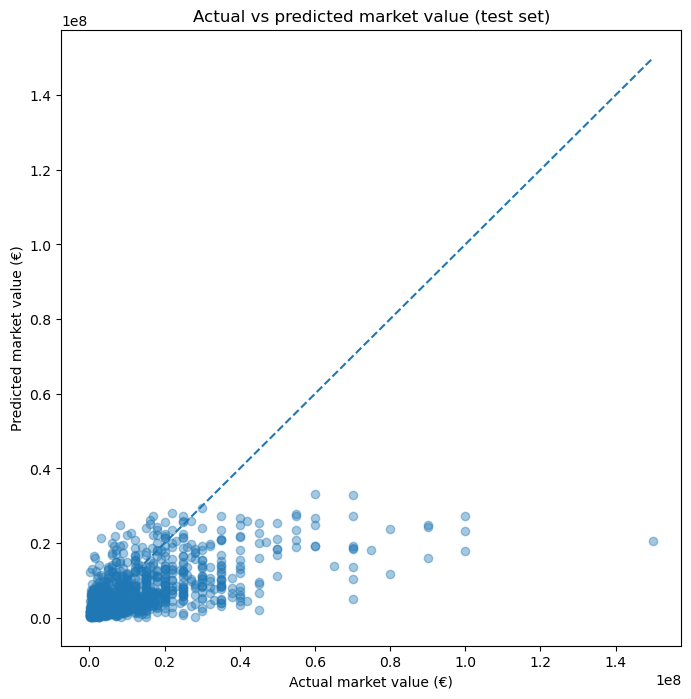

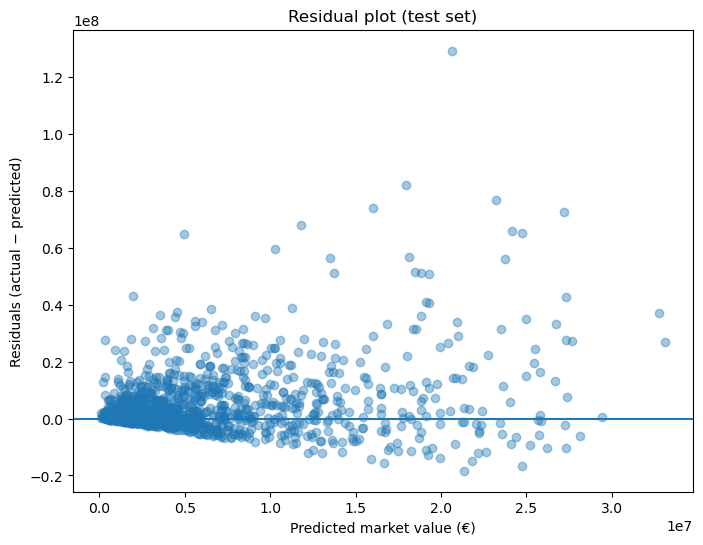

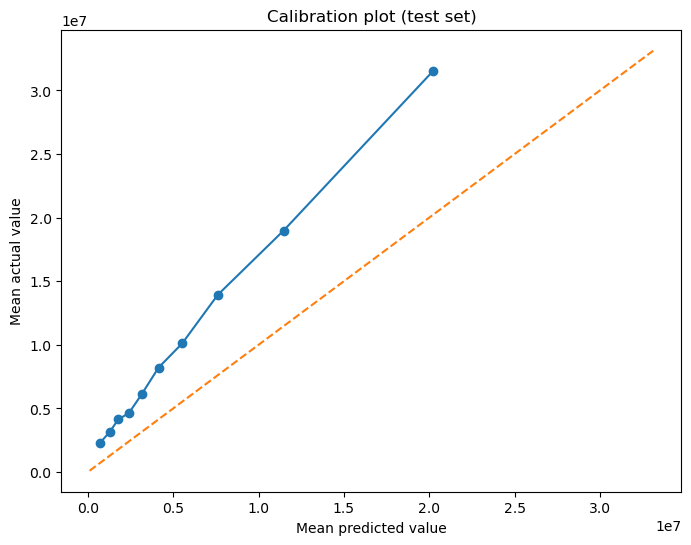

In [8]:
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.4)
max_val = max(np.max(y_true), np.max(y_pred))
min_val = min(np.min(y_true), np.min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual market value (€)")
plt.ylabel("Predicted market value (€)")
plt.title("Actual vs predicted market value (test set)")
plt.show()

residuals = y_true - y_pred.flatten()
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0)
plt.xlabel("Predicted market value (€)")
plt.ylabel("Residuals (actual − predicted)")
plt.title("Residual plot (test set)")
plt.show()

df_cal = pd.DataFrame({"y_true": y_true, "y_pred": y_pred.flatten()})
df_cal["bin"] = pd.qcut(df_cal["y_pred"], q=10, duplicates="drop")
calibration = df_cal.groupby("bin", observed=True).mean()
plt.figure(figsize=(8, 6))
plt.plot(calibration["y_pred"], calibration["y_true"], marker="o")
plt.plot(
    [df_cal["y_pred"].min(), df_cal["y_pred"].max()],
    [df_cal["y_pred"].min(), df_cal["y_pred"].max()],
    linestyle="--",
)
plt.xlabel("Mean predicted value")
plt.ylabel("Mean actual value")
plt.title("Calibration plot (test set)")
plt.show()